# 第 4 关 · 传令兵

消息传递编码器。邻居之间开始互相传消息，今天模型第一次真的好用。

今天还会第一次量**配对有效率**——第 5 关要和它比。

**BOSS：恢复率 ≥ 第 3 关 + 3 个百分点**

---

**这一关有 6 个部分：**

0. 准备
1. 把一层消息传递拆开看
2. 搭模型
3. 训练
4. 配对有效率：今天模型的那个洞
5. 层数实验与 BOSS

## 部分 0 · 准备

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd()
while not (ROOT / "minif").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
print("仓库根：", ROOT)

from minif.plotting import setup
plt = setup()

仓库根： /Users/bf/Documents/GitHub/rna-protein-inverse-folding


In [2]:
import numpy as np
import torch
import torch.nn as nn

from minif import data, engine, features as F, paths, scoreboard
from minif.model import EncLayer
from minif.plotting import tidy, PALETTE

MOL = "rna"
tr = data.load(MOL, "train"); va = data.load(MOL, "val")
data.describe(tr, "训练集："); data.describe(va, "验证集：")

训练集：295 条，长度 30-118（平均 68），总残基 20176，配对 6638 对
验证集：21 条，长度 30-70（平均 45），总残基 941，配对 298 对


## 部分 1 · 把一层消息传递拆开看

昨天：邻居信息简单平均。今天：每个邻居 j 根据（我自己、邻居 j、我俩之间的几何）
算出一条消息，我把收到的消息平均起来加到自己身上。

**代码只有十几行，但这是整个图神经网络的全部。** 先盯住形状。

In [3]:
import inspect
print(inspect.getsource(EncLayer))

class EncLayer(nn.Module):
    """一层消息传递：每个残基收集 k 个邻居传来的消息，加到自己身上。

    形状：h [L,D]，e [L,k,De]，idx [L,k] -> h [L,D]
    邻居用 mean 聚合，所以邻居的先后顺序不影响结果（图上本来也没有顺序）。
    """

    def __init__(self, d, d_edge, d_hidden):
        super().__init__()
        self.msg = mlp(2 * d + d_edge, d_hidden, d)
        self.ff = mlp(d, d_hidden, d)
        self.norm1 = nn.LayerNorm(d)
        self.norm2 = nn.LayerNorm(d)

    def forward(self, h, e, idx):
        hj = h[idx]                                   # [L,k,D] 邻居的向量
        hi = h.unsqueeze(1).expand_as(hj)             # [L,k,D] 自己的向量，复制 k 份
        m = self.msg(torch.cat([hi, hj, e], dim=-1))  # [L,k,D]
        h = self.norm1(h + m.mean(dim=1))
        h = self.norm2(h + self.ff(h))
        return h



In [4]:
# 亲手跑一层，把每一步的形状打出来
V, E, idx, seq = engine.prep(tr[0], MOL)
L, k = idx.shape
D = 128
embed_V, embed_E = nn.Linear(V.shape[-1], D), nn.Linear(E.shape[-1], D)
layer = EncLayer(D, D, D)

h, e = embed_V(V), embed_E(E)
print("h  (每个核苷酸一个向量)     ", tuple(h.shape))
print("e  (每条边一个向量)         ", tuple(e.shape))
print("idx(谁是谁的邻居)           ", tuple(idx.shape))
print()
hj = h[idx]
hi = h.unsqueeze(1).expand_as(hj)
print("hj 邻居的向量                ", tuple(hj.shape))
print("hi 自己的向量，复制 k 份      ", tuple(hi.shape))
print("拼起来喂进消息网络            ", tuple(torch.cat([hi, hj, e], -1).shape))
print()
out = layer(h, e, idx)
print("一层之后 h                   ", tuple(out.shape), " <- 形状没变，内容变了")

h  (每个核苷酸一个向量)      (82, 128)
e  (每条边一个向量)          (82, 16, 128)
idx(谁是谁的邻居)            (82, 16)

hj 邻居的向量                 (82, 16, 128)
hi 自己的向量，复制 k 份       (82, 16, 128)
拼起来喂进消息网络             (82, 16, 384)

一层之后 h                    (82, 128)  <- 形状没变，内容变了


In [5]:
# 邻居用 mean 聚合，所以邻居的先后顺序不影响结果（图上本来就没有顺序）
perm = torch.randperm(k)
with torch.no_grad():
    a = layer(h, e, idx)
    b = layer(h, e[:, perm], idx[:, perm])
print("打乱邻居顺序后最大差 %.1e  （应该≈0）" % (a - b).abs().max().item())

打乱邻居顺序后最大差 4.8e-07  （应该≈0）


## 部分 2 · 搭模型

嵌入 → 3 层消息传递 → 线性头输出 4 个碱基的分数。
叠 3 层，信息就能传 3 跳远。

In [6]:
class EncoderOnly(nn.Module):
    def __init__(self, d_node, d_edge, n_out, d=128, n_layers=3):
        super().__init__()
        self.embed_V = nn.Linear(d_node, d)
        self.embed_E = nn.Linear(d_edge, d)
        self.layers = nn.ModuleList([EncLayer(d, d, d) for _ in range(n_layers)])
        self.out = nn.Linear(d, n_out)

    def forward(self, V, E, idx):
        h, e = self.embed_V(V), self.embed_E(E)
        for layer in self.layers:
            h = layer(h, e, idx)
        return self.out(h)

model = EncoderOnly(F.node_dim(MOL), F.edge_dim(MOL), F.n_letters(MOL))
print("参数量", sum(p.numel() for p in model.parameters()))

参数量 436100


## 部分 3 · 训练

60 轮，训练时给坐标加 0.02Å 噪声——别让模型靠晶体结构的微小细节作弊。

In [7]:
best = engine.fit(model, tr, va, MOL, epochs=60, lr=1e-3, noise=0.02,
                  autoregressive=False, log_every=5,
                  save=paths.run_file("level4.pt"), level=4, eval_pairs=True)

  ep  1  训练 loss 1.312 恢复 38.5%   验证 loss 1.295 恢复 40.1%   最好 40.1%  [4s]
  ep  5  训练 loss 0.825 恢复 67.4%   验证 loss 1.008 恢复 61.3%   最好 61.3%  [17s]
  ep 10  训练 loss 0.496 恢复 81.7%   验证 loss 1.187 恢复 60.1%   最好 61.3%  [33s]
  ep 15  训练 loss 0.301 恢复 89.1%   验证 loss 1.341 恢复 64.8%   最好 64.8%  [50s]
  ep 20  训练 loss 0.204 恢复 92.9%   验证 loss 1.491 恢复 65.9%   最好 65.9%  [66s]
  ep 25  训练 loss 0.140 恢复 95.0%   验证 loss 1.807 恢复 65.0%   最好 65.9%  [83s]
  ep 30  训练 loss 0.118 恢复 96.0%   验证 loss 1.952 恢复 63.9%   最好 66.0%  [99s]
  ep 35  训练 loss 0.098 恢复 96.7%   验证 loss 2.098 恢复 64.7%   最好 66.0%  [116s]
  ep 40  训练 loss 0.091 恢复 96.9%   验证 loss 2.092 恢复 64.4%   最好 66.0%  [132s]
  ep 45  训练 loss 0.073 恢复 97.5%   验证 loss 2.010 恢复 65.2%   最好 66.3%  [149s]
  ep 50  训练 loss 0.064 恢复 97.8%   验证 loss 2.214 恢复 64.5%   最好 66.3%  [165s]
  ep 55  训练 loss 0.059 恢复 98.1%   验证 loss 2.221 恢复 64.4%   最好 66.3%  [181s]
  ep 60  训练 loss 0.052 恢复 98.3%   验证 loss 2.176 恢复 67.9%   最好 67.9%  [201s]

验证集最好恢复率：67.9%
配对有效

## 部分 4 · 配对有效率：今天模型的那个洞

恢复率在 RNA 上偏钝。换个指标：**天然结构里配对的那些位置上，
设计出来的两个碱基还配不配得上？**

今天的模型每个位置独立预测——算第 7 位时它不知道第 40 位会选什么。
所以茎区会配不上。把这个数字记下来，明天要和它比。

In [8]:
from minif import pairing
r = max(va, key=lambda x: (x["partner"] >= 0).sum())
des = engine.design(model, r, MOL, temperature=0.3, autoregressive=False)
dots = "".join("(" if 0 <= p and p > i else (")" if p >= 0 else ".")
               for i, p in enumerate(r["partner"]))
print(r["id"])
print("配对  ", dots)
print("天然  ", r["seq"]); pairing.summarize(r["seq"], r["partner"], "        ")
print("设计  ", des);      pairing.summarize(des, r["partner"], "        ")

9HRF_A
配对   (((((((.((.(((((((((((((((((....))))))))).(.)))(...))))))))).)))))))..
天然   GGGCGCAUUUUGGUAGGUCGGUCGCUGCUUCGGCAGUGAGGGGUAGGCAUUGCUGGCCUAGGGUGCCCUU
        配对 28 对，有效 86%   组成：GC=7 CG=7 其他=4 UA=4 GU=3 UG=2 AU=1
设计   GGGCGCAAUUUGGGCGGUCGGUCGCCGCUUCGGCGGUGAGGAGUAGGCUUUGCUGGCCUGUGGUGCCCCA
        配对 28 对，有效 79%   组成：CG=8 GC=7 其他=6 GU=3 UG=2 UA=2


0.7857142857142857

In [9]:
pv = scoreboard.read()["levels"]["4"].get("pair_validity")
print("第 4 关配对有效率 %.1f%%  <- 明天要比它高至少 5 个百分点" % (100*pv) if pv else "没记上")

第 4 关配对有效率 71.9%  <- 明天要比它高至少 5 个百分点


## 部分 5 · 层数实验与 BOSS

层数和恢复率是什么关系？为什么不是越多越好？

In [10]:
res = {}
for n in (1, 3, 6):
    m = EncoderOnly(F.node_dim(MOL), F.edge_dim(MOL), F.n_letters(MOL), n_layers=n)
    res[n] = engine.fit(m, tr, va, MOL, epochs=20, lr=1e-3, noise=0.02,
                        autoregressive=False, log_every=20, eval_pairs=False)
    print("%d 层 -> %.1f%%\n" % (n, 100*res[n]))

  ep  1  训练 loss 1.302 恢复 38.6%   验证 loss 1.195 恢复 48.0%   最好 48.0%  [2s]
  ep 20  训练 loss 0.379 恢复 85.9%   验证 loss 1.614 恢复 57.9%   最好 60.6%  [30s]

验证集最好恢复率：60.6%
1 层 -> 60.6%

  ep  1  训练 loss 1.315 恢复 37.8%   验证 loss 1.269 恢复 45.2%   最好 45.2%  [3s]
  ep 20  训练 loss 0.190 恢复 93.5%   验证 loss 1.645 恢复 61.8%   最好 64.9%  [66s]

验证集最好恢复率：64.9%
3 层 -> 64.9%

  ep  1  训练 loss 1.307 恢复 38.7%   验证 loss 1.190 恢复 49.4%   最好 49.4%  [6s]
  ep 20  训练 loss 0.145 恢复 94.9%   验证 loss 1.657 恢复 64.8%   最好 64.9%  [121s]

验证集最好恢复率：64.9%
6 层 -> 64.9%



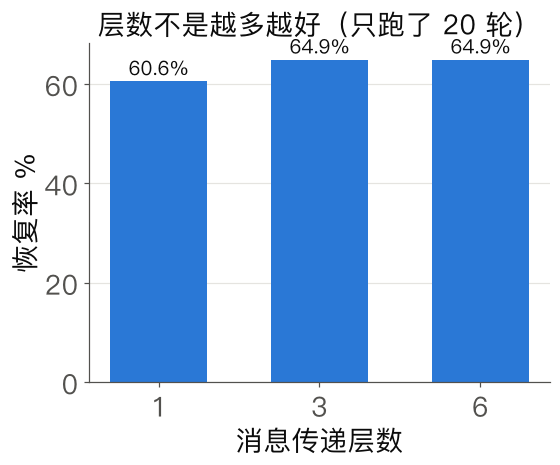

In [12]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "PingFang SC"
plt.rcParams["axes.unicode_minus"] = False
fig, ax = plt.subplots(figsize=(5.4, 4))
ns = list(res); vs = [100*res[n] for n in ns]
ax.bar([str(n) for n in ns], vs, color=PALETTE[0], width=.6)
for x, v in zip(range(len(ns)), vs):
    ax.annotate("%.1f%%" % v, (x, v), xytext=(0, 4), textcoords="offset points",
                ha="center", fontsize=13)
ax.set_xlabel("消息传递层数"); ax.set_ylabel("恢复率 %")
ax.set_title("层数不是越多越好（只跑了 20 轮）")
tidy(ax); plt.show()

In [13]:
!cd .. && python game.py check 4


  ── 第 4 关 BOSS：传令兵 ──
  要求：恢复率 ≥ 第 3 关 + 3 个百分点

  ✔ 恢复率 67.9% ≥ 上一关 53.3% + 3.0（现在超出 +14.6 个百分点）

  通过。第 4 关已通关。
  ★ 解锁成就：不看攻略·第4关



## 自测

1. 一条消息里包含哪三样东西？为什么邻居用 mean 聚合而不是拼起来？
2. 拿张纸画：3 层消息传递后，一个核苷酸的信息能影响到多远？
3. 训练时给坐标加噪声是为了什么？设 `noise=0` 跑一次对比。
4. **用一句话说清楚**：这个模型设计出来的序列，在茎区里为什么会配不上？

写进 `notes/level4.md`。